## Import packages

In [17]:
# If using Google Colab, uncomment the following line
# !pip install rasterio

import sys
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import torch                                            # Main PyTorch library
from datetime import datetime                           # Date/time utilities
import os                                               # Operating system utilities
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data

import deepSSF_model                                    # Import the .py file containing the deepSSF model                                          

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')

# To save the images, create a directory
base_dir = f'outputs/landscape_predictions'
os.makedirs(base_dir, exist_ok=True)
print(f"Base output directory: {base_dir}")

3.12.5 | packaged by Anaconda, Inc. | (main, Sep 12 2024, 18:18:29) [MSC v.1929 64 bit (AMD64)]
Base output directory: outputs/landscape_predictions


### If using Google Colab, uncomment the following lines

The file directories will also need to be changed to match the location of the files in your Google Drive.

In [18]:
# from google.colab import drive
# drive.mount('/content/drive')

## Import the GPS data

We only use this for selecting a spatial extent for the area we want to predict over.

In [19]:
# select the id of that data that the model was trained on
buffalo_id = 2005
n_samples = 10297 # 2005 has 10297 samples

# Specify the path to your CSV file
csv_file_path = f'../buffalo_local_data_id/buffalo_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'

# Read the CSV file into a DataFrame
buffalo_df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame
print(buffalo_df.head())

             x_            y_                    t_    id           x1_  \
0  41969.310875 -1.435671e+06  2018-07-25T01:04:23Z  2005  41969.310875   
1  41921.521939 -1.435654e+06  2018-07-25T02:04:39Z  2005  41921.521939   
2  41779.439594 -1.435601e+06  2018-07-25T03:04:17Z  2005  41779.439594   
3  41841.203272 -1.435635e+06  2018-07-25T04:04:39Z  2005  41841.203272   
4  41655.463332 -1.435604e+06  2018-07-25T05:04:27Z  2005  41655.463332   

            y1_           x2_           y2_     x2_cent    y2_cent  ...  \
0 -1.435671e+06  41921.521939 -1.435654e+06  -47.788936  16.857110  ...   
1 -1.435654e+06  41779.439594 -1.435601e+06 -142.082345  53.568427  ...   
2 -1.435601e+06  41841.203272 -1.435635e+06   61.763677 -34.322938  ...   
3 -1.435635e+06  41655.463332 -1.435604e+06 -185.739939  31.003534  ...   
4 -1.435604e+06  41618.651923 -1.435608e+06  -36.811409  -4.438037  ...   

         ta    cos_ta         x_min         x_max         y_min         y_max  \
0  1.367942  0.20

# Importing spatial data

Instead of importing the stacks of local layers (one for each step), here can import the spatial covariates at any extent, which we can predict the habitat selection over. We use an extent that covers all of the observed locations, which refer to as the 'landscape'.

## NDVI

We have NDVI layers for every month of the year for 2018 and 2019, so we will just import a few examples for illustration.

In [20]:
file_path_ndvi_aug2018 = '../mapping/cropped rasters/ndvi_aug_2018.tif'
file_path_ndvi_feb2019 = '../mapping/cropped rasters/ndvi_feb_2019.tif'

# read the raster file
with rasterio.open(file_path_ndvi_aug2018) as src:
    # Read the raster band as separate variable
    ndvi_aug2018 = src.read(1)
    # Get the metadata of the raster
    ndvi_meta_aug2018 = src.meta
    # Get the transform of the raster for transforming pixels to the raster CRS
    raster_transform = src.transform

with rasterio.open(file_path_ndvi_feb2019) as src:
    # Read the raster band as separate variable
    ndvi_feb2019 = src.read(1)
    # Get the metadata of the raster
    ndvi_meta_feb2019 = src.meta


### Prepare the NDVI data

There are a few things we need to do to prepare the landscape layers. 

First, we need to ensure that there are no NA values in the data. For NDVI we will replace any NA values with -1 (which denotes water), as in our case that is typically why they were set to NA. 

Secondly, the model expects the covariates to on *the same scale as the training data*. We will therefore scale the NDVI data using the same max and min scaling parameters as the training data. To get these, there are some min and max print statements in the `deepSSF_train.ipynb` script. When we plot the NDVI data below we will see that the values will no longer range from 0 to 1, which is because there are values in the landscape layers that are outside of the range of the training data.

NDVI metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["GDA94 / Geoscience Australia Lambert",UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Affine transformation parameters:
| 25.00, 0.00, 0.00|
| 0.00,-25.00,-1406000.00|
| 0.00, 0.00, 1.00|


Shape of the raster:
(2280, 2400)


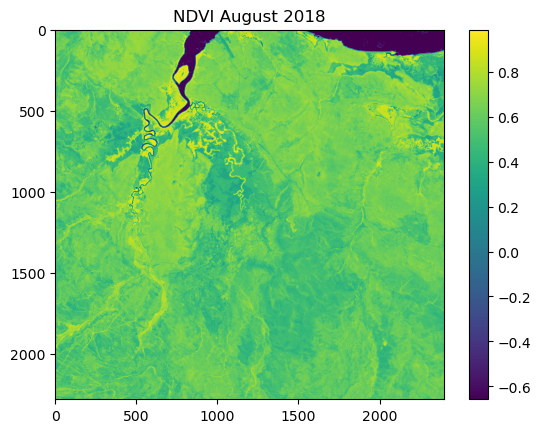

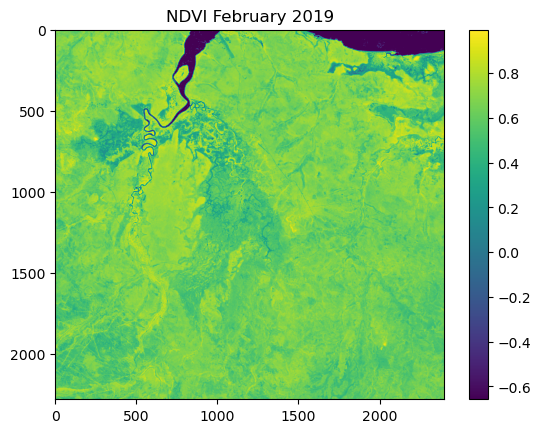

In [21]:
# Check the coordinate reference system
print("NDVI metadata:")
print(ndvi_meta_aug2018)
print("\n")

# Have a look at the affine transformation parameters that are used to convert pixel 
# coordinates to geographic coordinates and vice versa
print("Affine transformation parameters:")
print(raster_transform)
print("\n")

# Check the shape (row, columns) of the raster
print("Shape of the raster:")
print(ndvi_aug2018.shape)

# Replace NaNs in the original array with -1, which represents water
ndvi_aug2018 = np.nan_to_num(ndvi_aug2018, nan=-1.0)
ndvi_feb2019 = np.nan_to_num(ndvi_feb2019, nan=-1.0)

# Create a water mask:
# For pixels where ndvi equals -1.0 (representing water), assign -np.inf.
# For all other pixels, assign 1.
water_mask = np.where(ndvi_aug2018 == -1.0, -np.inf, 1)

# from the stack of local layers (training data)
ndvi_max = 0.8220
ndvi_min = -0.2772

# Convert the numpy arrays to PyTorch tensors
ndvi_aug2018_tens = torch.from_numpy(ndvi_aug2018)
ndvi_feb2019_tens = torch.from_numpy(ndvi_feb2019)

# Normalising the data
ndvi_aug2018_norm = (ndvi_aug2018_tens - ndvi_min) / (ndvi_max - ndvi_min)
ndvi_feb2019_norm = (ndvi_feb2019_tens - ndvi_min) / (ndvi_max - ndvi_min)

plt.imshow(ndvi_aug2018_norm.numpy())
plt.colorbar()
plt.title('NDVI August 2018')
plt.show()

plt.imshow(ndvi_feb2019_norm.numpy())
plt.colorbar()
plt.title('NDVI February 2019')
plt.show()


## Canopy cover

Canopy cover is just a single static layer.

In [22]:
# Path to the canopy cover raster file
file_path = '../mapping/cropped rasters/canopy_cover.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    canopy_landscape = src.read(1)
    # Get the metadata of the raster
    canopy_meta = src.meta

### Prepare the canopy cover data

As with the NDVI data, we need to ensure that there are no NA values in the data. 

As the canopy cover values in the landscape layer are within the same range as the training data, we see that the values range from 0 to 1.

Canopy metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["GDA94 / Geoscience Australia Lambert",UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of canopy raster:
(2280, 2400)


Number of NA values in the canopy raster:
0


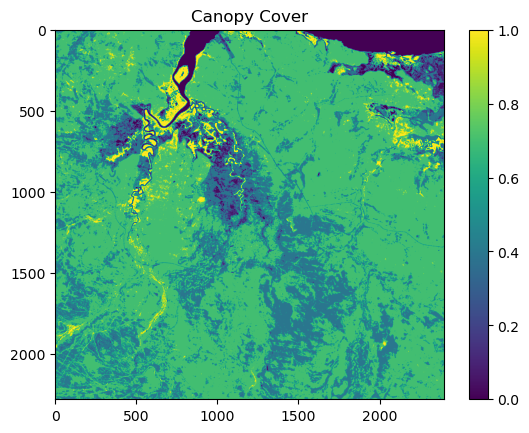

In [23]:
# Check the canopy metadata:
print("Canopy metadata:")
print(canopy_meta)
print("\n")

# Check the shape (rows, columns) of the canopy raster:
print("Shape of canopy raster:")
print(canopy_landscape.shape)
print("\n")

# Check for NA values in the canopy raster:
print("Number of NA values in the canopy raster:")
print(np.isnan(canopy_landscape).sum())

# Define the maximum and minimum canopy values from the stack of local layers:
canopy_max = 82.5000
canopy_min = 0.0

# Convert the canopy data from a NumPy array to a PyTorch tensor:
canopy_landscape_tens = torch.from_numpy(canopy_landscape)

# Normalise the canopy data:
canopy_landscape_norm = (canopy_landscape_tens - canopy_min) / (canopy_max - canopy_min)

# Visualise the normalised canopy cover:
plt.imshow(canopy_landscape_norm.numpy())
plt.colorbar()
plt.title('Canopy Cover')
plt.show()


## Herbaceous vegetation

In [24]:
# Path to the herbaceous vegetation raster file
file_path = '../mapping/cropped rasters/veg_herby.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    herby_landscape = src.read(1)
    # Get the metadata of the raster
    herby_meta = src.meta

Herbaceous metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["GDA94 / Geoscience Australia Lambert",UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of herbaceous raster:
(2280, 2400)


Number of NA values in the herbaceous vegetation raster:
0


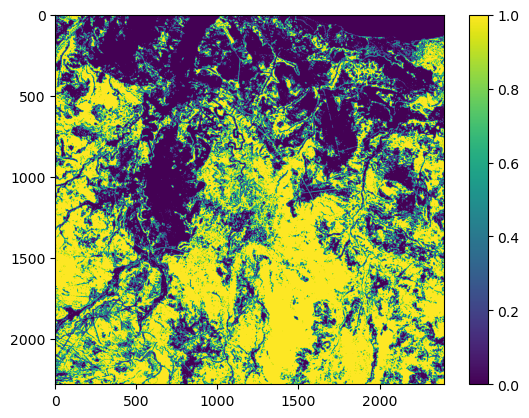

In [25]:
# Check the herbaceous metadata:
print("Herbaceous metadata:")
print(herby_meta)
print("\n")

# Check the shape (rows, columns) of the herbaceous raster:
print("Shape of herbaceous raster:")
print(herby_landscape.shape)
print("\n")

# Check for NA values in the herby raster:
print("Number of NA values in the herbaceous vegetation raster:")
print(np.isnan(herby_landscape).sum())

# Define the maximum and minimum herbaceous values from the stack of local layers:
herby_max = 1.0
herby_min = 0.0

# Convert the herbaceous data from a NumPy array to a PyTorch tensor:
herby_landscape_tens = torch.from_numpy(herby_landscape)

# Normalize the herbaceous data:
herby_landscape_norm = (herby_landscape_tens - herby_min) / (herby_max - herby_min)

# Visualize the normalised herbaceous cover:
plt.imshow(herby_landscape_norm.numpy())
plt.colorbar()
plt.show()


## Slope

In [26]:
# Path to the slope raster file
file_path = '../mapping/cropped rasters/slope.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    slope_landscape = src.read(1)
    # Get the metadata of the raster
    slope_meta = src.meta

Slope metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('LOCAL_CS["GDA94 / Geoscience Australia Lambert",UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of slope landscape raster:
(2280, 2400)


Number of NA values in the slope raster:
9356


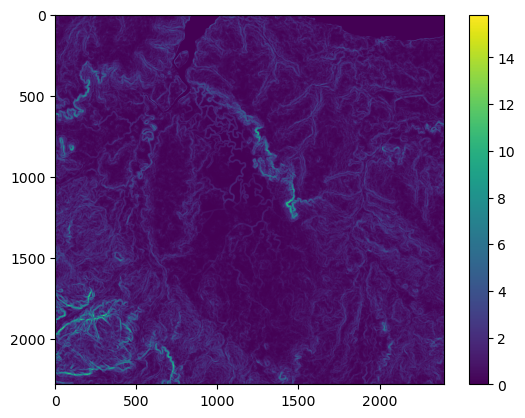

In [27]:
# Check the slope metadata:
print("Slope metadata:")
print(slope_meta)
print("\n")

# Check the shape (rows, columns) of the slope landscape raster:
print("Shape of slope landscape raster:")
print(slope_landscape.shape)
print("\n")

# Check for NA values in the slope raster:
print("Number of NA values in the slope raster:")
print(np.isnan(slope_landscape).sum())

# Replace NaNs in the slope array with 0.0 (representing water):
slope_landscape = np.nan_to_num(slope_landscape, nan=0.0)

# Define the maximum and minimum slope values from the stack of local layers:
slope_max = 12.2981
slope_min = 0.0006

# Convert the slope landscape data from a NumPy array to a PyTorch tensor:
slope_landscape_tens = torch.from_numpy(slope_landscape)

# Normalize the slope landscape data:
slope_landscape_norm = (slope_landscape_tens - slope_min) / (slope_max - slope_min)

# Visualize the slope landscape (note: displaying the original tensor, not the normalised data):
plt.imshow(slope_landscape_tens.numpy())
plt.colorbar()
plt.show()


# Prepare data for running the model

## Select a smaller extent of the landscape

To illustrate the approach, we will select a smaller extent of the landscape to predict over, which covers the spatial extent of the training data. 

In [28]:
# from the buffalo data
buffer = 1250
min_x = min(buffalo_df['x_']) - buffer
max_x = max(buffalo_df['x_']) + buffer
min_y = min(buffalo_df['y_']) - buffer
max_y = max(buffalo_df['y_']) + buffer

# custom extent in epsg:3112
# min_x = 28148.969145
# max_x = 47719.496935
# min_y = -1442210.335861
# max_y = -1433133.681746

# Convert geographic coordinates to pixel coordinates
min_px, min_py = ~raster_transform * (min_x, min_y)
print(min_px, min_py)
max_px, max_py = ~raster_transform * (max_x, max_y)
print(max_px, max_py)

# Round pixel coordinates to integers
min_px, max_px, min_py, max_py = int(round(min_px)), \
    int(round(max_px)), \
        int(round(min_py)), \
            int(round(max_py))

# Print the pixel coordinates	
print(f"Min x = {min_px}, Max x = {max_px}, \nMin y = {min_py}, Max y = {max_py}")

1091.3389860694217 1546.6350942641802
2166.104503472696 888.6517715825685
Min x = 1091, Max x = 2166, 
Min y = 1547, Max y = 889


## Subset all layers

Here we want to crop the layers to the spatial extent defined above. 

For plotting purposes, we convert the normalised landscape layers back to their natural scale. This is only for plotting and are not used for modelling. 

We also calculate the minimum and maximum values of the normalised landscape subsets, which we will use to define the colour scale when plotting the layers.

In [29]:
# Initialize a subset array with zeros (or another padding value) with the dimensions defined by the pixel indices.
subset = np.zeros((min_py - max_py, max_px - min_px), dtype=ndvi_aug2018.dtype)

# Extract the subsets of each normalised raster using the defined pixel boundaries.
ndvi_aug2018_subset = ndvi_aug2018_norm[max_py:min_py, min_px:max_px]
ndvi_feb2019_subset = ndvi_feb2019_norm[max_py:min_py, min_px:max_px]
canopy_subset = canopy_landscape_norm[max_py:min_py, min_px:max_px]
herby_subset = herby_landscape_norm[max_py:min_py, min_px:max_px]
slope_subset = slope_landscape_norm[max_py:min_py, min_px:max_px]

# Convert normalised NDVI values back to their natural scale by reversing the normalisation.
ndvi_aug2018_subset_natural = ndvi_aug2018_subset * (ndvi_max - ndvi_min) + ndvi_min
ndvi_feb2019_subset_natural = ndvi_feb2019_subset * (ndvi_max - ndvi_min) + ndvi_min

# Convert normalised canopy, herbaceous, and slope values back to their natural scales.
canopy_subset_natural = canopy_subset * (canopy_max - canopy_min) + canopy_min
herby_subset_natural = herby_subset * (herby_max - herby_min) + herby_min
slope_subset_natural = slope_subset * (slope_max - slope_min) + slope_min

# Determine the minimum NDVI value across the two layers (natural scale).
ndvi_plot_min = min(ndvi_aug2018_subset_natural.min(), 
                    ndvi_feb2019_subset_natural.min())
print(f"Minimum NDVI value across layers {ndvi_plot_min}")

# Determine the maximum NDVI value across the three layers (natural scale).
ndvi_plot_max = max(ndvi_aug2018_subset_natural.max(), 
                    ndvi_feb2019_subset_natural.max())
print(f"Maximum NDVI value across layers {ndvi_plot_max}")


Minimum NDVI value across layers -0.289407879114151
Maximum NDVI value across layers 0.7880553007125854


### Create a directory for output images

In [30]:
# Output directory for saving plots
base_id_dir = f'{base_dir}/id{buffalo_id}_{today_date}'
os.makedirs(base_id_dir, exist_ok=True)
print(f"Output directory: {base_id_dir}")

Output directory: outputs/landscape_predictions/id2005_2025-04-14


### Plot the landscape subsets

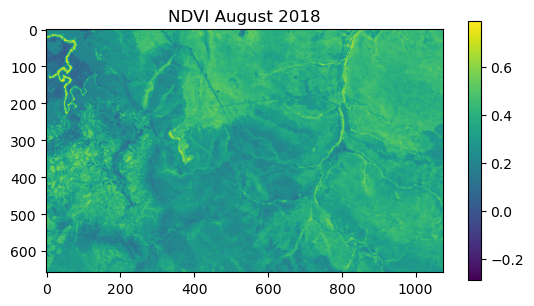

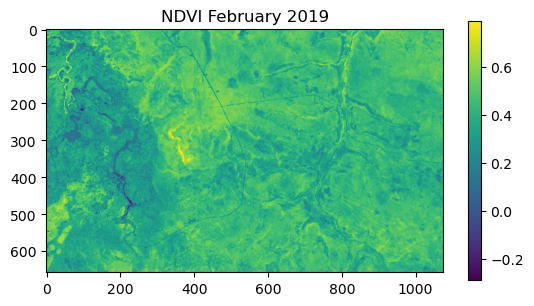

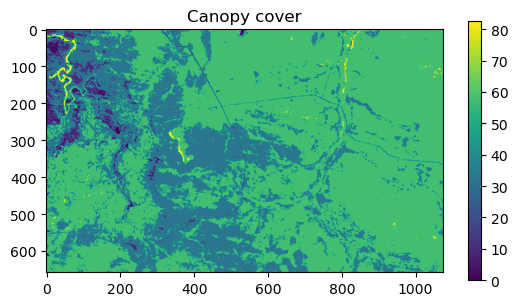

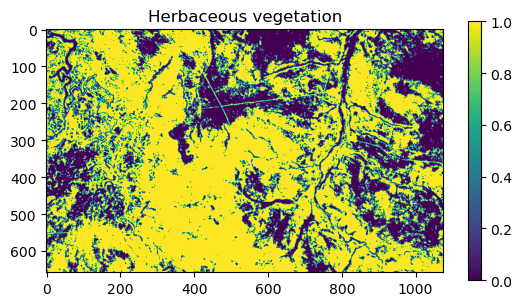

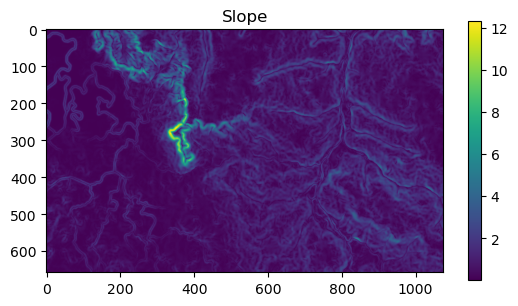

In [31]:
# NDVI August 2018
plt.imshow(ndvi_aug2018_subset_natural, cmap='viridis', vmin=ndvi_plot_min, vmax=ndvi_plot_max)
plt.colorbar(shrink=0.7)
plt.title(f'NDVI August 2018')
plt.savefig(f"{base_id_dir}/id{buffalo_id}_ndvi_aug2018.png", 
            dpi=600, bbox_inches='tight')
plt.show()
plt.close()  # Close the figure to free memory

# NDVI February 2019
plt.imshow(ndvi_feb2019_subset_natural, cmap='viridis', vmin=ndvi_plot_min, vmax=ndvi_plot_max)
plt.colorbar(shrink=0.7)
plt.title(f'NDVI February 2019')
plt.savefig(f"{base_id_dir}/id{buffalo_id}_ndvi_feb2019.png", 
            dpi=600, bbox_inches='tight')
plt.show()
plt.close()  # Close the figure to free memory

# Canopy cover
plt.imshow(canopy_subset_natural, cmap='viridis')
plt.colorbar(shrink=0.7)
plt.title(f'Canopy cover')
plt.savefig(f"{base_id_dir}/id{buffalo_id}_canopy_cover.png", 
            dpi=600, bbox_inches='tight')
plt.show()
plt.close()  # Close the figure to free memory

# Herbaceous vegetation
plt.imshow(herby_subset_natural, cmap='viridis')
plt.colorbar(shrink=0.7)
plt.title(f'Herbaceous vegetation')
plt.savefig(f"{base_id_dir}/id{buffalo_id}_herby_veg.png", 
            dpi=600, bbox_inches='tight')
plt.show()
plt.close()  # Close the figure to free memory

# Slope
plt.imshow(slope_subset_natural, cmap='viridis')
plt.colorbar(shrink=0.7)
plt.title(f'Slope')
plt.savefig(f"{base_id_dir}/id{buffalo_id}_slope.png", 
            dpi=600, bbox_inches='tight')
plt.show()
plt.close()  # Close the figure to free memory

# Load the model

### Set the device for the model

In [32]:
# run on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using {device} device")

Using cpu device


## Define the parameters for the model

Here we enter the specific parameter values and hyperparameters for the model. 
These are the values that will be used to instantiate the model.

In [33]:
# Define the parameters for the model
params_dict = {"batch_size": 32, #number of samples in each batch
               "image_dim": 101, #number of pixels along the edge of each local patch/image
               "pixel_size": 25, #number of metres along the edge of a pixel
               "dim_in_nonspatial_to_grid": 4, #the number of scalar predictors that are converted to a grid and appended to the spatial features
               "dense_dim_in_nonspatial": 4, #change this to however many other scalar predictors you have (bearing, velocity etc)
               "dense_dim_hidden": 128, #number of nodes in the hidden layers
               "dense_dim_out": 128, #number of nodes in the output of the fully connected block (FCN)
               "dense_dim_in_all": 10000,# + 128, #number of inputs entering the fully connected block once the nonspatial features have been concatenated to the spatial features
               "input_channels": 4 + 4, #number of spatial layers in each image + number of scalar layers that are converted to a grid
               "output_channels": 4, #number of filters to learn
               "kernel_size": 3, #the size of the 2D moving windows / kernels that are being learned
               "stride": 1, #the stride used when applying the kernel.  This reduces the dimension of the output if set to greater than 1
               "kernel_size_mp": 2, #the size of the kernel that is used in max pooling operations
               "stride_mp": 2, #the stride that is used in max pooling operations
               "padding": 1, #the amount of padding to apply to images prior to applying the 2D convolution
               "num_movement_params": 12, #number of parameters used to parameterise the movement kernel
               "dropout": 0.1, #the proportion of nodes that are dropped out in the dropout layers
               "device": device
               }

As described in the `deepSSF_train.ipynb` script, we saved the model definition into a file named `deepSSF_model.py`. We can instantiate the model by importing the file (which was done when importing other packages) and calling the classes parameter dictionary from that script.

In [34]:
params = deepSSF_model.ModelParams(params_dict)
model = deepSSF_model.ConvJointModel(params).to(device)
print(model)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (fcn_movement_all): FCN_block_all_movement(
    (ffn): Sequential(
      (0): Linear(in_features=10000, out_features=128, bias=True)
      (1): Dropout(p=0.1, inplace=False)
      (2): ReLU()
      (3): Linea

In [ ]:
# # load the model weights
# print(model.state_dict())
model.load_state_dict(torch.load(f'outputs/model_training/id2005_med_2_2025-04-14/checkpoint_deepSSF_buffalo2005.pt', 
                                 map_location=torch.device('cpu'),
                                 weights_only=True))
# print(model.state_dict())
# model.eval()

<All keys matched successfully>

# Run habitat selection subnetwork on landscape layers

## Select which NDVI layer to use for prediction

Now that we have layers for the full landscape area, as well as the subset defined by the observed locations, we can select which layers to use for prediction. We will use the subset layers, but just comment and uncomment the appropriate lines to use the full landscape layers.

Additionally, to run the model we need to select a single NDVI layer to predict over. For illustration, we will use the NDVI layer from August 2018, and set the input parameter corresponding to the day of the year to be within that month.

In [36]:
# To use the full extent
# ndvi_landscape = ndvi_aug2018_norm
# ndvi_landscape = ndvi_feb2019_norm
# canopy_landscape = canopy_landscape_norm
# herby_landscape = herby_landscape_norm
# slope_landscape = slope_landscape_norm

# To use the subset extent
ndvi_landscape = ndvi_aug2018_subset
# ndvi_landscape = ndvi_feb2019_subset
canopy_landscape = canopy_subset
herby_landscape = herby_subset
slope_landscape = slope_subset

## Prepare the scalar covariates

We also need the hour of the day and day of the year to predict with (as the model was trained with these as inputs). 

In this example we'll select a single hour and a single day of the year to predict over, and then below we'll loop over the hours of the day to illustrate the temporal variation in habitat selection that was learned by the model.

In [37]:
# Hour of the day (hour) 
hour_t2 = 6
# Convert to sine and cosine (as this is what the model expects)
hour_t2_sin = np.sin(2*np.pi*hour_t2/24)
hour_t2_cos = np.cos(2*np.pi*hour_t2/24)

# Day of the year (yday)
yday_t2 = 225
# Convert to sine and cosine
yday_t2_sin = np.sin(2*np.pi*yday_t2/365)
yday_t2_cos = np.cos(2*np.pi*yday_t2/365)

# Convert the numpy scalars to PyTorch tensors and ensure they are float type.
# unsqueeze(0) adds a batch dimension.
hour_t2_sin_tensor = torch.tensor(hour_t2_sin).float().unsqueeze(0)
hour_t2_cos_tensor = torch.tensor(hour_t2_cos).float().unsqueeze(0)
yday_t2_sin_tensor = torch.tensor(yday_t2_sin).float().unsqueeze(0)
yday_t2_cos_tensor = torch.tensor(yday_t2_cos).float().unsqueeze(0)

def scalar_to_grid(x, dim_x, dim_y):
    """
    Reshape a scalar tensor to a grid with the given dimensions.
    
    Args:
        x (torch.Tensor): Input scalar tensor of shape [1].
        dim_x (int): Number of rows for the grid.
        dim_y (int): Number of columns for the grid.
        
    Returns:
        torch.Tensor: Tensor expanded to shape [1, 1, dim_x, dim_y].
    """
    # View x as shape [1, 1, 1, 1] and expand to a grid of shape [1, 1, dim_x, dim_y]
    scalar_map = x.view(1, 1, 1, 1).expand(1, 1, dim_x, dim_y)
    return scalar_map

# Stack the scalar tensors along a new dimension (dim=0) to form a tensor with shape [4, 1]
# representing the four covariates: hour sin, hour cos, day-of-year sin, day-of-year cos.
scalar_covariates = torch.stack([
    hour_t2_sin_tensor, 
    hour_t2_cos_tensor, 
    yday_t2_sin_tensor, 
    yday_t2_cos_tensor
], dim=0)
print(scalar_covariates.shape)  # Expected shape: [4, 1]

# Convert each scalar covariate into a grid matching the dimensions of the NDVI landscape.
# This creates spatial maps where each grid cell contains the same scalar value.
scalar_grids = torch.cat([
    scalar_to_grid(tensor, ndvi_landscape.shape[0], ndvi_landscape.shape[1]) 
    for tensor in scalar_covariates
], dim=1)
print(scalar_grids.shape)  # Expected shape: [1, 4, rows, cols]

torch.Size([4, 1])
torch.Size([1, 4, 658, 1075])


## Combine the spatial and scalar (as grid) covariates

In [38]:
# Stack the individual landscape layers (NDVI, canopy, herbaceous, and slope) into a single tensor.
# The resulting tensor has shape [4, rows, cols].
landscape_stack = torch.stack([ndvi_landscape, canopy_landscape, herby_landscape, slope_landscape], dim=0)

# Add an extra batch dimension to the tensor.
# Now the shape becomes [1, 4, rows, cols], where 1 indicates a single sample.
landscape_stack = landscape_stack.unsqueeze(0)
print(landscape_stack.shape)

# Concatenate the landscape stack with the scalar grids along the channel dimension.
# This merges the spatial features (landscape_stack) and the repeated scalar covariate grids (scalar_grids)
# into a full feature tensor with shape [1, total_channels, rows, cols].
full_stack = torch.cat([landscape_stack, scalar_grids], dim=1)
print(full_stack.shape)

torch.Size([1, 4, 658, 1075])
torch.Size([1, 8, 658, 1075])


## Run habitat selection subnetwork on the landscape layers

All we need to do to run the habitat selection subnetwork of the model is to pull that component out of the model and run it on the landscape layers.

In [39]:
# Pass the full feature stack through the habitat convolutional layer of the model to get predictions.
landscape_predictions = model.conv_habitat(full_stack)

# Print the shape of the output tensor to verify the dimensions of the predictions.
print(landscape_predictions.shape)

torch.Size([1, 658, 1075])


## Plot the predictions

Create a directory with a folder for the day of the year.

In [40]:
# To save the images, create a directory
base_id_day_dir = f'{base_id_dir}/yday{yday_t2}'
os.makedirs(base_id_day_dir, exist_ok=True)
print(f"Output directory: {base_id_day_dir}")

Output directory: outputs/landscape_predictions/id2005_2025-04-14/yday225


As the spatial inputs are padded by the model, there are artifacts at the edges of the predictions. Sometimes this can result in quite different values to the rest of the predictions, which changes the colour scale. To prevent this we remove the outer pixels of the predictions.

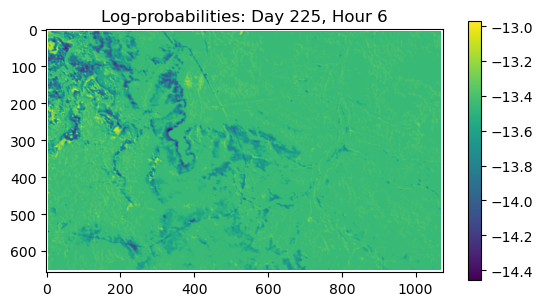

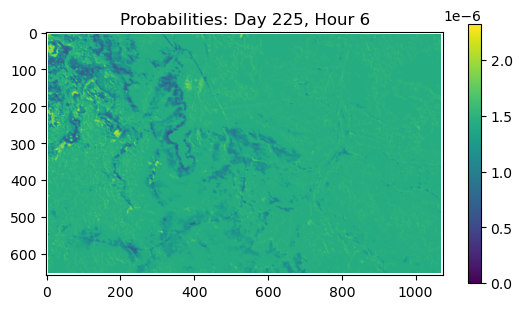

In [41]:
# Extract the first sample from the output tensor, detach it from the computational graph,
# move it to the CPU, and convert it to a NumPy array for further processing and visualization.
output_image = landscape_predictions[0].detach().cpu().numpy()

# Create masks for the x and y coordinates, as well as a water mask (unused in the code below),
# with the same shape as the output image.
x_mask = np.ones_like(output_image)
y_mask = np.ones_like(output_image)
water_mask = np.ones_like(output_image)

# Get the dimensions of the output image.
y_dim = output_image.shape[0]
x_dim = output_image.shape[1]

# Define a buffer value to mask out edge cells.
buffer = 3

# Apply the buffer mask to the x-axis: set the first and last 'buffer' columns to -infinity.
x_mask[:, :buffer] = -np.inf
x_mask[:, x_dim - buffer:] = -np.inf

# Apply the buffer mask to the y-axis: set the first and last 'buffer' rows to -infinity.
y_mask[:buffer, :] = -np.inf
y_mask[y_dim - buffer:, :] = -np.inf

# Mask out edge cells in the output image by multiplying with the x and y masks.
# Also mask out water cells by multiplying with the water mask.
output_image = output_image * x_mask * y_mask
output_image = output_image * water_mask

# Plot the masked output image using the 'viridis' colormap.
plt.imshow(output_image, cmap='viridis')
plt.colorbar(shrink=0.7)  # Display the color scale.
plt.title(f'Log-probabilities: Day {yday_t2}, Hour {hour_t2}')
# Define the filename for saving the landscape prediction image
plt.savefig(f"{base_id_day_dir}/id{buffalo_id}_hab_log_prob_yday{yday_t2}_hour{hour_t2}.png", 
            dpi=600, bbox_inches='tight') 
plt.show()
plt.close()  # Close the figure to free up memory.

# Plot the exponential of the output image, which may be used to convert log-probabilities
# back to probability values.
plt.imshow(np.exp(output_image), cmap='viridis')
plt.colorbar(shrink=0.7)  # Display the color scale.
plt.title(f'Probabilities: Day {yday_t2}, Hour {hour_t2}')
# Define the filename for saving the landscape prediction image
plt.savefig(f"{base_id_day_dir}/id{buffalo_id}_hab_prob_yday{yday_t2}_hour{hour_t2}.png", 
            dpi=600, bbox_inches='tight') 
plt.show()
plt.close()  # Close the figure to free up memory.

## Extracting prediction values

To assess how the covariates are affecting the predictions, we can extract the prediction values and correlate them with values of the landscape layers. This allows us to assess the marginal effect of each covariate on the predictions, which can look across the day and the year. 

In [42]:
# Flatten the tensors and convert to numpy arrays
ndvi_array = ndvi_landscape
ndvi_array = ndvi_array.flatten()

canopy_array = canopy_landscape
canopy_array = canopy_array.flatten()

herby_array = herby_landscape
herby_array = herby_array.flatten()

slope_array = slope_landscape.detach().numpy()
slope_array = slope_array.flatten()

landscape_predictions_array = torch.exp(landscape_predictions).detach().numpy()
landscape_predictions_array = landscape_predictions_array * x_mask * y_mask
landscape_predictions_array = landscape_predictions_array.flatten()

# Create a single DataFrame with updated column names
df = pd.DataFrame({
    'NDVI': ndvi_array,
    'Canopy_cover': canopy_array,
    'Herbaceous_vegetation': herby_array,
    'Slope': slope_array,
    'Predictions': landscape_predictions_array
})

# Display a slice of the DataFrame
print(f"Number of cells = {len(df)}")
# Select some cells that aren't in the masked regions
print(df[15000:15010])

# Export the DataFrame to a CSV file
df.to_csv(f"{base_id_day_dir}/id{buffalo_id}_habitat_selection_landscape_subset_yday{yday_t2}_hour{hour_t2}.csv", index=False)

Number of cells = 707350
           NDVI  Canopy_cover  Herbaceous_vegetation     Slope  Predictions
15000  0.629553       0.69697                    1.0  0.185803     0.000001
15001  0.601575       0.69697                    1.0  0.179693     0.000001
15002  0.624586       0.69697                    1.0  0.173530     0.000001
15003  0.657760       0.69697                    0.0  0.164683     0.000001
15004  0.655190       0.69697                    0.0  0.150086     0.000001
15005  0.632485       0.69697                    1.0  0.132480     0.000001
15006  0.610266       0.69697                    1.0  0.113604     0.000001
15007  0.583366       0.69697                    1.0  0.077426     0.000001
15008  0.580902       0.69697                    1.0  0.010272     0.000001
15009  0.581040       0.69697                    1.0  0.084885     0.000001


## Plot the correlation between the predictions and the covariates

It is a bit hard to see the effects here with so many points being plotted, so we'll do some more processing and plotting in R, so we'll just create and export the dataframes here.

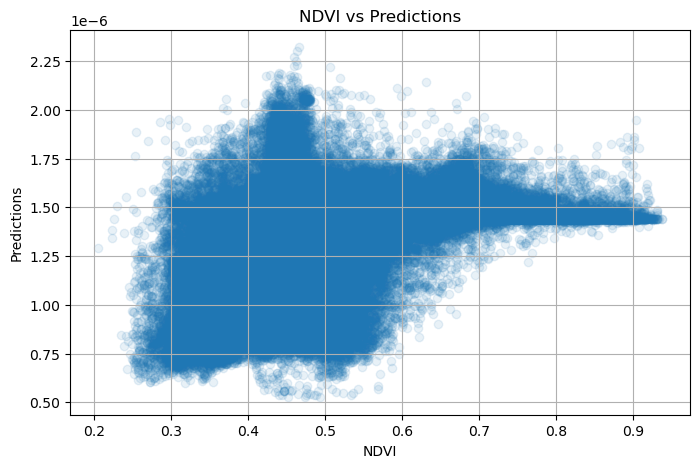

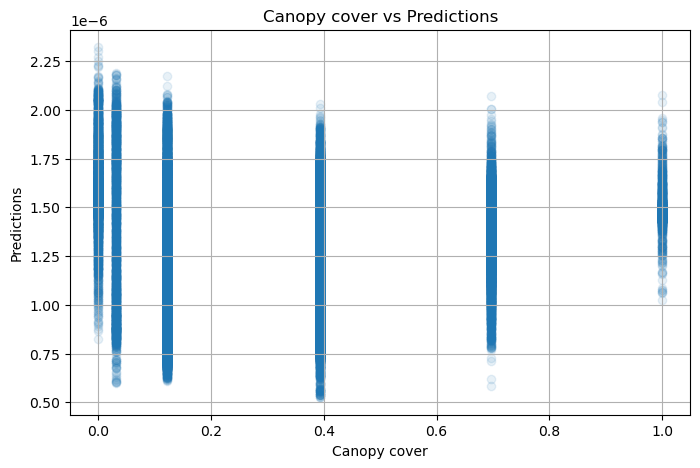

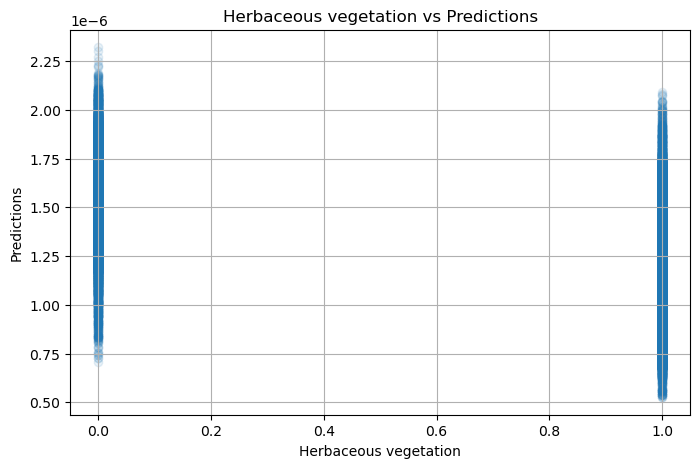

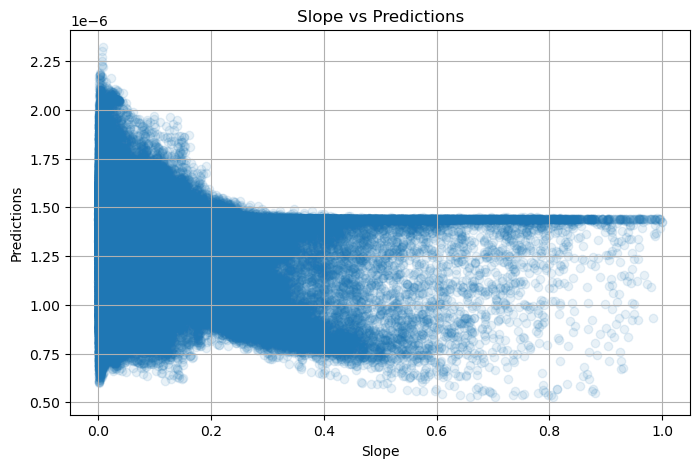

In [43]:
# Plot the data with plt.scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['NDVI'], df['Predictions'], alpha=0.1)
plt.title('NDVI vs Predictions')
plt.xlabel('NDVI')
plt.ylabel('Predictions')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Canopy_cover'], df['Predictions'], alpha=0.1)
plt.title('Canopy cover vs Predictions')
plt.xlabel('Canopy cover')
plt.ylabel('Predictions')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Herbaceous_vegetation'], df['Predictions'], alpha=0.1)
plt.title('Herbaceous vegetation vs Predictions')
plt.xlabel('Herbaceous vegetation')
plt.ylabel('Predictions')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Slope'], df['Predictions'], alpha=0.1)
plt.title('Slope vs Predictions')
plt.xlabel('Slope')
plt.ylabel('Predictions')
plt.grid(True)
plt.show()

## Loop over hours

A benefit of the `deepSSF` approach is that it can represent temporal variation in habitat selection (and movement dynamics) across the day, which interacts with the day of the year. 

To illustrate this, we can loop over the hours of the day and predict the habitat selection at each hour. We can also assess the contribution of each covariate to the predictions at each hour, giving us some idea of what the model has learned about the temporal variation in habitat selection, which can help us to further understand our species' spatial ecology.

Here are some examples:

**Day 45 - February 14th - wet season**

![](../figures/landscape_preds_yday45.gif)


**Day 250 - August 13th - dry season**

![](../figures/landscape_preds_yday225.gif)

In [44]:
# To plot the prediction maps with the same colour scale, 
# we need to determine the minimum and maximum values
# Initialize landscape min and max values
landscape_vmin = float('inf')
landscape_vmax = float('-inf')

### Select the day of the year

We will select a single day of the year to predict over, and then loop over the hours of the day.

Ensure that the correct NDVI layer is selected for the day of the year.
- Day 225 is in August, so we will use the NDVI layer from August 2018.
- Day 45 is in February, so we will use the NDVI layer from February 2019.

In [52]:
yday_t2 = 225 # corresponds to the August 2018 NDVI layer
# yday_t2 = 45 # corresponds to the February 2019 NDVI layer

# To use the full extent
# ndvi_landscape = ndvi_aug2018_norm
# ndvi_landscape = ndvi_feb2019_norm

# To use the subset extent
ndvi_landscape = ndvi_aug2018_subset
# ndvi_landscape = ndvi_feb2019_subset

# Convert to sine and cosine
yday_t2_sin = np.sin(2*np.pi*yday_t2/365)
yday_t2_cos = np.cos(2*np.pi*yday_t2/365)

Update the directory with the correct day of the year.

In [53]:
# To save the images, create a directory
base_id_day_dir = f'{base_id_dir}/yday{yday_t2}'
os.makedirs(base_id_day_dir, exist_ok=True)
print(f"Output directory: {base_id_day_dir}")

Output directory: outputs/landscape_predictions/id2005_2025-04-14/yday225


As we need to run over the full loop to get the `landscape_vmin` and `landscape_vmax` values, we will first run the loop over the hours of the day once without plotting (which is much faster), and then in the following code chunk run over the loop again but plot the predictions and save the images.

This loop generates the predictions and saves the probability values as a csv to correlate with covariate values (which we do in R).

In [54]:
# Create a single DataFrame with updated column names
df_hourly = pd.DataFrame({
    'NDVI': ndvi_array,
    'Canopy_cover': canopy_array,
    'Herbaceous_vegetation': herby_array,
    'Slope': slope_array
})

# Define the range of hours you want to loop over
hours = range(1,25) # to start at 1

# As we used sine and cosine terms to represent the hour of the day,
# rather than the hour as integers, we can use a continuous range of hours
# (Uncomment line below)
# hours = np.arange(0,24, 0.1)

for hour_t2 in hours:

    # convert hour to sine and cosine
    hour_t2_sin = np.sin(2*np.pi*hour_t2/24)
    hour_t2_cos = np.cos(2*np.pi*hour_t2/24)

    # Convert numpy objects to PyTorch tensors
    hour_t2_sin_tensor = torch.tensor(hour_t2_sin).float().unsqueeze(0)
    hour_t2_cos_tensor = torch.tensor(hour_t2_cos).float().unsqueeze(0)
    yday_t2_sin_tensor = torch.tensor(yday_t2_sin).float().unsqueeze(0)
    yday_t2_cos_tensor = torch.tensor(yday_t2_cos).float().unsqueeze(0)

    # Stack tensors column-wise to create a tensor of shape 
    scalar_covariates = torch.stack([hour_t2_sin_tensor, 
                                     hour_t2_cos_tensor, 
                                     yday_t2_sin_tensor, 
                                     yday_t2_cos_tensor], 
                                     dim=0)
    
    # Convert each scalar covariate into a grid matching the dimensions of the NDVI landscape
    scalar_grids = torch.cat([scalar_to_grid(tensor, 
                                             ndvi_landscape.shape[0], 
                                             ndvi_landscape.shape[1]) 
                                             for tensor in scalar_covariates
                                             ], dim=1)

    # Stack the spatial (landscape_stack) and scalar covariates (as grids)
    full_stack = torch.cat([landscape_stack, scalar_grids], dim=1)
    # print(full_stack.shape) # Expected shape: [1, n_channels, rows, cols]

    # Run the model
    landscape_predictions = model.conv_habitat(full_stack)
    # print(landscape_predictions.shape)

    # Pull out the prediction
    output_image = landscape_predictions[0].detach().cpu().numpy()

    # Mask out cells on the edges (that affect the colour scale)
    output_image = output_image * x_mask * y_mask

    # Check if output_image is valid before updating landscape min and max
    if output_image.size > 0:
        # Ignore masked values in the calculation
        valid_values = output_image[np.isfinite(output_image)]
        if valid_values.size > 0:
            current_min = valid_values.min()
            current_max = valid_values.max()
            # Update landscape min and max values for scaling the colour map
            landscape_vmin = min(landscape_vmin, current_min)
            landscape_vmax = max(landscape_vmax, current_max)

    predictions_array = np.exp(output_image).flatten()
    df_hourly[f'{hour_t2}'] = predictions_array

# Export the DataFrame to a CSV file
df_hourly.to_csv(f"{base_id_day_dir}/id{buffalo_id}_hourly_habitat_suitability_landscape_subset_yday{yday_t2}.csv", index=False)

print(landscape_vmin, landscape_vmax)

-15.939218 -11.245768


In this chunk we generate the plots (now the `landscape_vmin` and `landscape_vmax` values are set) and save them to the output directory.

We can save both the log-probabilities and the probabilities in their natural scale. We've saved the images of the log-probabilities, but just uncomment the appropriate lines to save the images of the probabilities as well.

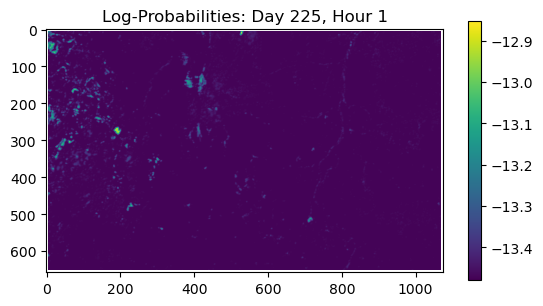

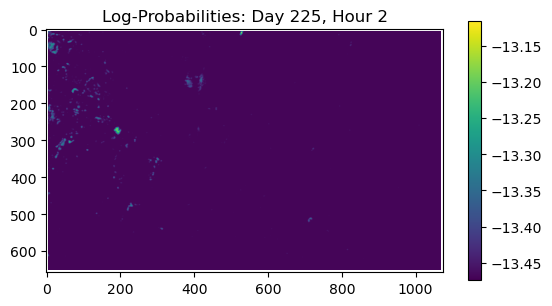

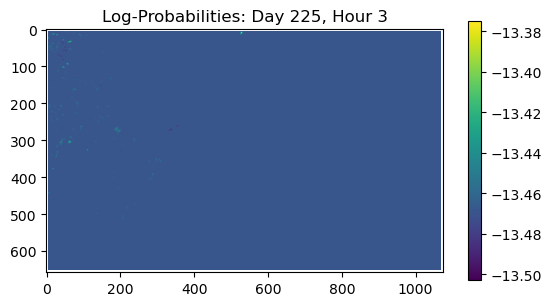

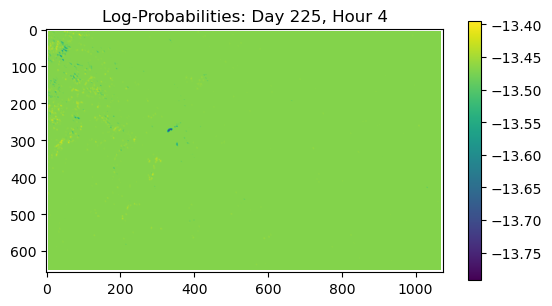

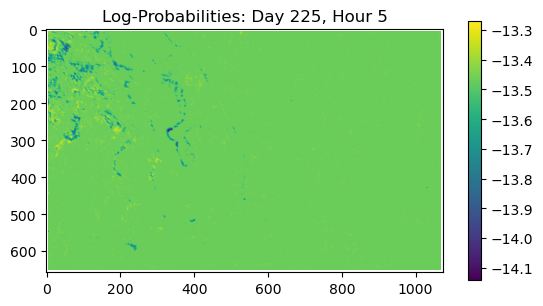

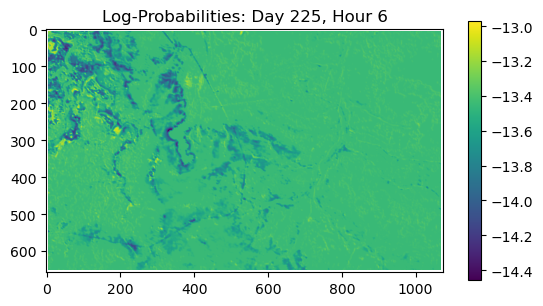

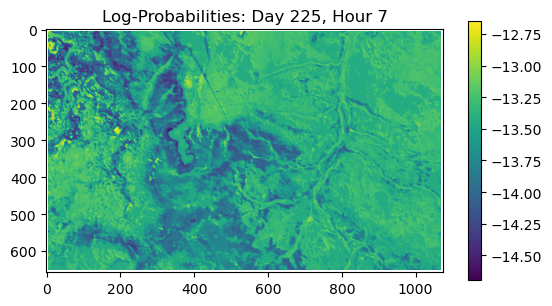

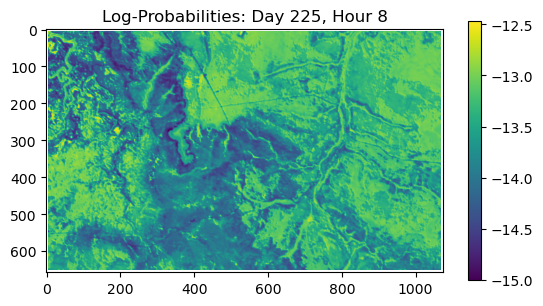

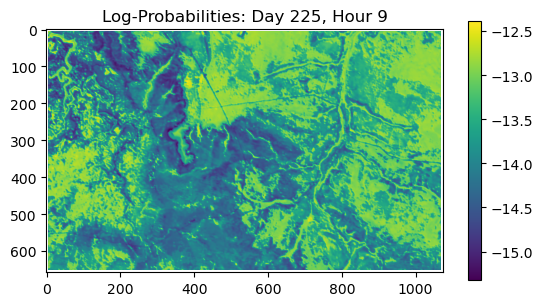

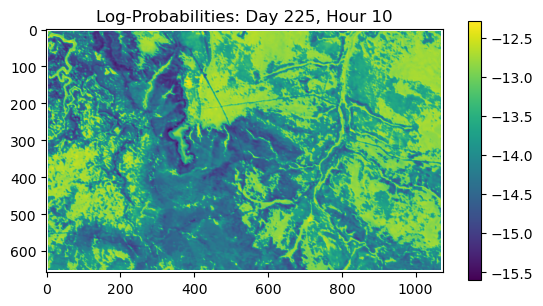

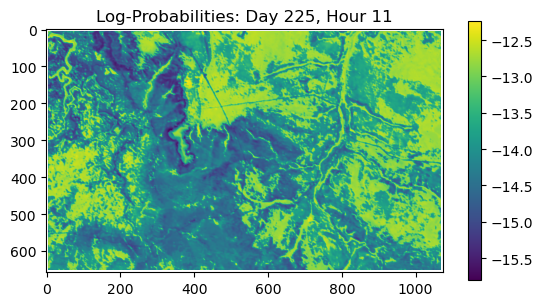

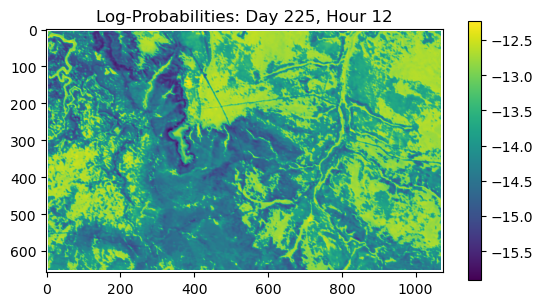

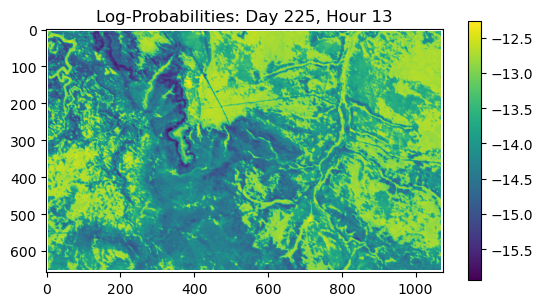

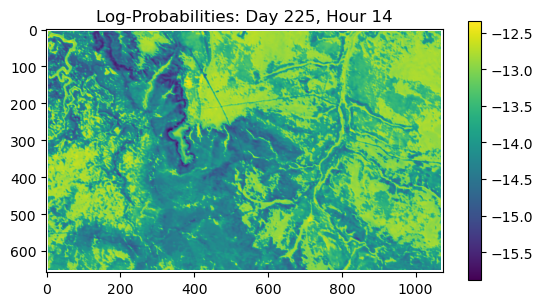

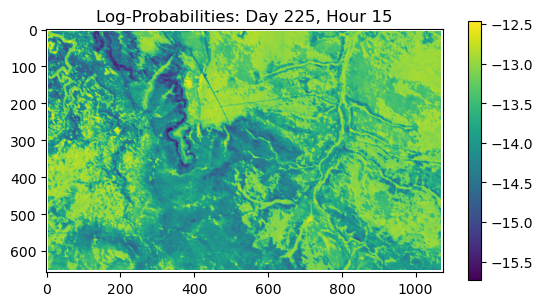

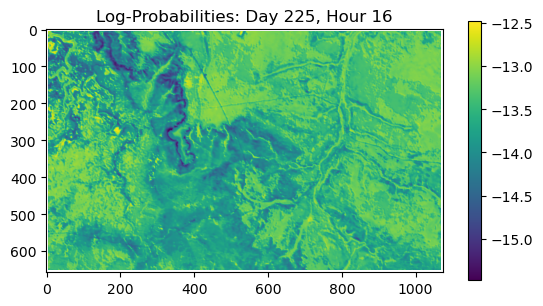

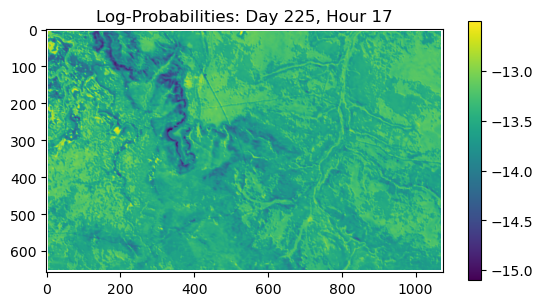

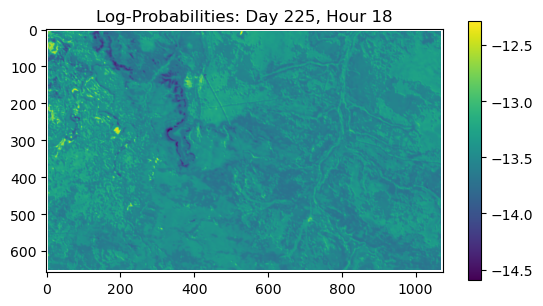

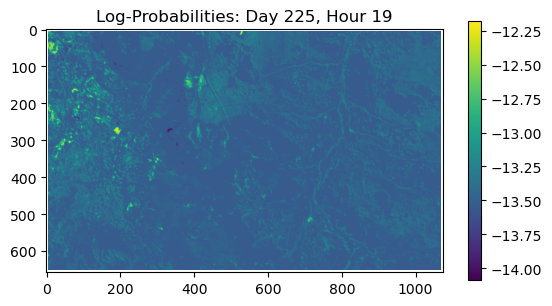

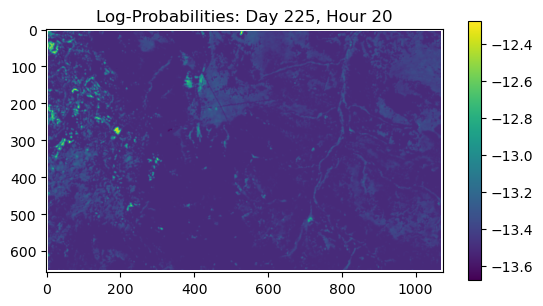

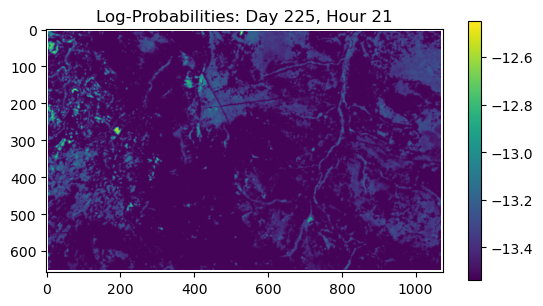

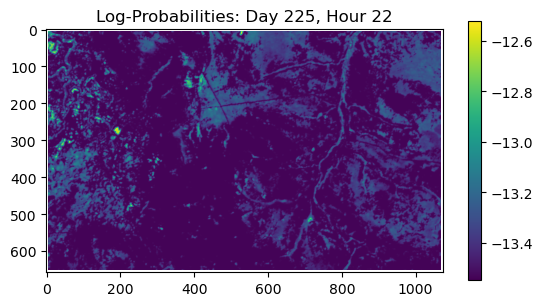

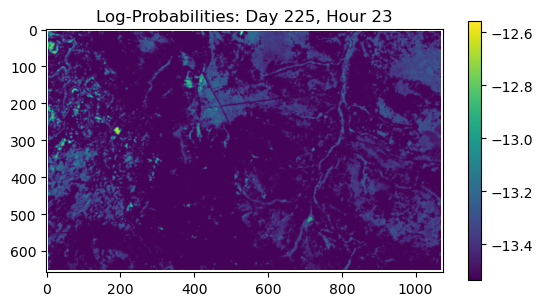

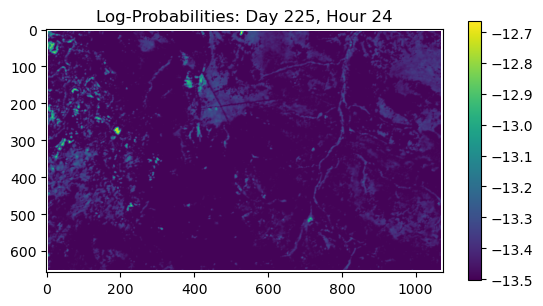

In [55]:
for hour_t2 in hours:

    # convert hour to sine and cosine
    hour_t2_sin = np.sin(2*np.pi*hour_t2/24)
    hour_t2_cos = np.cos(2*np.pi*hour_t2/24)

    # Convert numpy objects to PyTorch tensors
    hour_t2_sin_tensor = torch.tensor(hour_t2_sin).float().unsqueeze(0)
    hour_t2_cos_tensor = torch.tensor(hour_t2_cos).float().unsqueeze(0)
    yday_t2_sin_tensor = torch.tensor(yday_t2_sin).float().unsqueeze(0)
    yday_t2_cos_tensor = torch.tensor(yday_t2_cos).float().unsqueeze(0)

    # Stack tensors column-wise to create a tensor of shape 
    scalar_covariates = torch.stack([hour_t2_sin_tensor, 
                                     hour_t2_cos_tensor, 
                                     yday_t2_sin_tensor, 
                                     yday_t2_cos_tensor], 
                                     dim=0)
    
    # Convert each scalar covariate into a grid matching the dimensions of the NDVI landscape
    scalar_grids = torch.cat([scalar_to_grid(tensor, 
                                             ndvi_landscape.shape[0], 
                                             ndvi_landscape.shape[1]) 
                                             for tensor in scalar_covariates
                                             ], dim=1)

    # Stack the spatial (landscape_stack) and scalar covariates (as grids)
    full_stack = torch.cat([landscape_stack, scalar_grids], dim=1)
    # print(full_stack.shape) # Expected shape: [1, n_channels, rows, cols]

    # Run the model
    landscape_predictions = model.conv_habitat(full_stack)
    # print(landscape_predictions.shape)

    # Pull out the prediction
    output_image = landscape_predictions[0].detach().cpu().numpy()

    # Mask out cells on the edges (that affect the colour scale)
    output_image = output_image * x_mask * y_mask

    # Habitat selection log-probabilities
    filename_landscape_preds = f"{base_id_day_dir}/id{buffalo_id}_log_landscape_habitat_selection_yday{yday_t2}_hour{hour_t2}.png"
    plt.figure()  # Create a new figure
    plt.imshow(output_image) #, vmin=landscape_vmin, vmax=landscape_vmax)
    plt.colorbar(shrink=0.7)
    plt.title(f'Log-Probabilities: Day {yday_t2}, Hour {hour_t2}')
    plt.savefig(filename_landscape_preds, dpi=1000, bbox_inches='tight')
    plt.show()
    plt.close()  # Close the figure to free memory

    # # Habitat selection probabilities
    # filename_landscape_preds = f"{output_dir}/id{buffalo_id}_landscape_habitat_selection_yday{yday_t2}_hour{hour_t2}.png"
    # plt.figure()  # Create a new figure
    # plt.imshow(np.exp(output_image), vmin=np.exp(landscape_vmin), vmax=np.exp(landscape_vmax))
    # plt.colorbar(shrink=0.7)
    # plt.title(f'Probabilities: Day {yday_t2}, Hour {hour_t2}')
    # plt.savefig(filename_landscape_preds, dpi=600, bbox_inches='tight')
    # plt.show()
    # plt.close()  # Close the figure to free memory
